In [ ]:
# Importing standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Loading the dataset using kagglehub
import kagglehub
from kagglehub import KaggleDatasetAdapter

file_path = "zomato.csv"
df = kagglehub.dataset_load(KaggleDatasetAdapter.PANDAS,"himanshupoddar/zomato-bangalore-restaurants",file_path,)
print("First 5 records:", df.head())

Using Colab cache for faster access to the 'zomato-bangalore-restaurants' dataset.
First 5 records:                                                  url  \
0  https://www.zomato.com/bangalore/jalsa-banasha...   
1  https://www.zomato.com/bangalore/spice-elephan...   
2  https://www.zomato.com/SanchurroBangalore?cont...   
3  https://www.zomato.com/bangalore/addhuri-udupi...   
4  https://www.zomato.com/bangalore/grand-village...   

                                             address                   name  \
0  942, 21st Main Road, 2nd Stage, Banashankari, ...                  Jalsa   
1  2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...         Spice Elephant   
2  1112, Next to KIMS Medical College, 17th Cross...        San Churro Cafe   
3  1st Floor, Annakuteera, 3rd Stage, Banashankar...  Addhuri Udupi Bhojana   
4  10, 3rd Floor, Lakshmi Associates, Gandhi Baza...          Grand Village   

  online_order book_table   rate  votes                             phone  \
0          

In [ ]:
display(df.head())

,url,address,name,online_order,book_table,rate,votes,phone,location,rest_type,dish_liked,cuisines,approx_cost(for two people),reviews_list,menu_item,listed_in(type),listed_in(city)
0,https://www.zomato.com/bangalore/jalsa-banasha...,"942, 21st Main Road, 2nd Stage, Banashankari, ...",Jalsa,Yes,Yes,4.1/5,775,080 42297555\r\n+91 9743772233,Banashankari,Casual Dining,"Pasta, Lunch Buffet, Masala Papad, Paneer Laja...","North Indian, Mughlai, Chinese",800,"[('Rated 4.0', 'RATED\n A beautiful place to ...",[],Buffet,Banashankari
1,https://www.zomato.com/bangalore/spice-elephan...,"2nd Floor, 80 Feet Road, Near Big Bazaar, 6th ...",Spice Elephant,Yes,No,4.1/5,787,080 41714161,Banashankari,Casual Dining,"Momos, Lunch Buffet, Chocolate Nirvana, Thai G...","Chinese, North Indian, Thai",800,"[('Rated 4.0', 'RATED\n Had been here for din...",[],Buffet,Banashankari
2,https://www.zomato.com/SanchurroBangalore?cont...,"1112, Next to KIMS Medical College, 17th Cross...",San Churro Cafe,Yes,No,3.8/5,918,+91 9663487993,Banashankari,"Cafe, Casual Dining","Churros, Cannelloni, Minestrone Soup, Hot Choc...","Cafe, Mexican, Italian",800,"[('Rated 3.0', ""RATED\n Ambience is not that ...",[],Buffet,Banashankari
3,https://www.zomato.com/bangalore/addhuri-udupi...,"1st Floor, Annakuteera, 3rd Stage, Banashankar...",Addhuri Udupi Bhojana,No,No,3.7/5,88,+91 9620009302,Banashankari,Quick Bites,Masala Dosa,"South Indian, North Indian",300,"[('Rated 4.0', ""RATED\n Great food and proper...",[],Buffet,Banashankari
4,https://www.zomato.com/bangalore/grand-village...,"10, 3rd Floor, Lakshmi Associates, Gandhi Baza...",Grand Village,No,No,3.8/5,166,+91 8026612447\r\n+91 9901210005,Basavanagudi,Casual Dining,"Panipuri, Gol Gappe","North Indian, Rajasthani",600,"[('Rated 4.0', 'RATED\n Very good restaurant ...",[],Buffet,Banashankari


# Data Preprocessing



In [ ]:
df.describe() # Gives general statistical calculations

,votes
count,51717.000000
mean,283.697527
std,803.838853
min,0.000000
25%,7.000000
50%,41.000000
75%,198.000000
max,16832.000000


In [ ]:
df.info() # Gives overall information of the dataset

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51717 entries, 0 to 51716
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   url                          51717 non-null  object
 1   address                      51717 non-null  object
 2   name                         51717 non-null  object
 3   online_order                 51717 non-null  object
 4   book_table                   51717 non-null  object
 5   rate                         43942 non-null  object
 6   votes                        51717 non-null  int64 
 7   phone                        50509 non-null  object
 8   location                     51696 non-null  object
 9   rest_type                    51490 non-null  object
 10  dish_liked                   23639 non-null  object
 11  cuisines                     51672 non-null  object
 12  approx_cost(for two people)  51371 non-null  object
 13  reviews_list                 51

In [ ]:
df.count() # Gives the count of all values except null values

,0
url,51717
address,51717
name,51717
online_order,51717
book_table,51717
rate,43942
votes,51717
phone,50509
location,51696
rest_type,51490


In [ ]:
df.dtypes # Gives information about the data type of each column and object data type is used for columns which have mixed data

,0
url,object
address,object
name,object
online_order,object
book_table,object
rate,object
votes,int64
phone,object
location,object
rest_type,object


In [ ]:
df.isnull().sum() # Takes all null values in the columns and returns the sum of them

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,7775
votes,0
phone,1208
location,21
rest_type,227


In [ ]:
original_df = df.copy() # We keep an original copy of the dataset

In [ ]:
# We now fix errors within each column and convert each column to its proper data type

In [ ]:
# Columns such as url, address, name have no null values
# These columns are specific to the user and thus we do not need to edit them, so we can convert them to string columns

str_cols = ["url", "address", "name"]
df[str_cols] = df[str_cols].astype("string")

In [ ]:
print(df["rate"].value_counts(dropna = False)) # This shows different types of values in this column including null values
print(df["rate"].unique()) # This shows all the unique values in the column as a list

rate
NaN       7775
NEW       2208
3.9/5     2098
3.8/5     2022
3.7/5     2011
          ... 
2.2 /5       7
2.0 /5       7
2.0/5        4
1.8 /5       3
1.8/5        2
Name: count, Length: 65, dtype: int64
['4.1/5' '3.8/5' '3.7/5' '3.6/5' '4.6/5' '4.0/5' '4.2/5' '3.9/5' '3.1/5'
 '3.0/5' '3.2/5' '3.3/5' '2.8/5' '4.4/5' '4.3/5' 'NEW' '2.9/5' '3.5/5' nan
 '2.6/5' '3.8 /5' '3.4/5' '4.5/5' '2.5/5' '2.7/5' '4.7/5' '2.4/5' '2.2/5'
 '2.3/5' '3.4 /5' '-' '3.6 /5' '4.8/5' '3.9 /5' '4.2 /5' '4.0 /5' '4.1 /5'
 '3.7 /5' '3.1 /5' '2.9 /5' '3.3 /5' '2.8 /5' '3.5 /5' '2.7 /5' '2.5 /5'
 '3.2 /5' '2.6 /5' '4.5 /5' '4.3 /5' '4.4 /5' '4.9/5' '2.1/5' '2.0/5'
 '1.8/5' '4.6 /5' '4.9 /5' '3.0 /5' '4.8 /5' '2.3 /5' '4.7 /5' '2.4 /5'
 '2.1 /5' '2.2 /5' '2.0 /5' '1.8 /5']


In [ ]:
df["rate"] = df["rate"].replace(["-", "NEW"], np.nan) # We replaced "-" and "NEW" with null values to impute them later

# Since rating values are seperated by a slash, we will remove the slash and keep only the rating part
df["rate"] = df["rate"].apply(lambda x: float(str(x).split("/")[0]) if pd.notnull(x) else np.nan)

In [ ]:
print(df["phone"].value_counts(dropna = False))
print(df["phone"].unique())

phone
NaN                               1208
080 43334321                       216
080 43334333                       167
+91 7005889963                      78
+91 8197170008                      75
                                  ... 
+91 9066371426                       1
+91 9843354310                       1
+91 8970706965                       1
+91 8888499601\n+91 7259220781       1
+91 8951626034                       1
Name: count, Length: 14927, dtype: int64
['080 42297555\r\n+91 9743772233' '080 41714161' '+91 9663487993' ...
 '+91 9663517066\n+91 9686861135' '+91 9164562939' '080 65951222']


In [ ]:
# The phone column is very messy and thus we clean it step by step

df["phone"] = df["phone"].str.replace(r'^080\s+', '080', regex = True) # We remove extra spaces after 080 and join it with the other number
df["phone"] = df["phone"].str.replace(r'^\+91', '' , regex = True) # We remove +91 and keep the original number
df["phone"] = df["phone"].str.strip() # This removes extra spaces from start and end

In [ ]:
import re # Used for finding number patterns

# Here we create a function called extract_two_numbers(x) as we can see some customers have provided two numbers which are seperated by some characters

def extract_two_numbers(x):
    if pd.isnull(x) and str(x).strip() == "":
        return np.nan # If we have null or empty values, we will return null values

    x = str(x) # We will ensure all values are treated as a string

    numbers = re.findall(r'\d+', x) # It is used to find all digit sequences in the string

    valid_numbers = [num for num in numbers if len(num) in [10,11]] # This only keeps valid phone numbers

    if len(valid_numbers) >= 2:
        return f"{valid_numbers[0]}/{valid_numbers[1]}" # If multiple numbers, join them with a slash
    elif len(valid_numbers) == 1:
        return valid_numbers[0] # If single number, return the number
    else:
        return np.nan # If no number, return null value

df["phone"] = df["phone"].apply(extract_two_numbers) # We will apply the function to the phone column

In [ ]:
print(df.shape)
print(df["phone"].isnull().sum())

# We can see only a small fraction of values are null values for the values in the phone column
# So we can drop these null values and it is also difficult to impute such values

df = df.dropna(subset = ["phone"]).reset_index(drop = True) # This will remove null values from phone column and resets the index for each value

(51717, 17)
1402


In [ ]:
print(df["rest_type"].value_counts(dropna = False))
print(df["rest_type"].unique())
print(df["rest_type"].isnull().sum())

rest_type
Quick Bites                   18597
Casual Dining                 10205
Cafe                           3615
Delivery                       2481
Dessert Parlor                 2198
                              ...  
Dessert Parlor, Kiosk             2
Food Court, Beverage Shop         2
Sweet Shop, Dessert Parlor        1
Quick Bites, Kiosk                1
Bakery, Food Court                1
Name: count, Length: 92, dtype: int64
['Casual Dining' 'Cafe, Casual Dining' 'Quick Bites' 'Casual Dining, Cafe'
 'Cafe' 'Quick Bites, Cafe' 'Cafe, Quick Bites' 'Delivery' 'Mess'
 'Dessert Parlor' 'Bakery, Dessert Parlor' 'Pub' 'Bakery'
 'Takeaway, Delivery' 'Fine Dining' 'Beverage Shop' 'Sweet Shop' 'Bar'
 'Beverage Shop, Quick Bites' 'Confectionery' 'Quick Bites, Beverage Shop'
 'Dessert Parlor, Sweet Shop' 'Bakery, Quick Bites'
 'Sweet Shop, Quick Bites' 'Kiosk' 'Food Truck'
 'Quick Bites, Dessert Parlor' 'Beverage Shop, Dessert Parlor' 'Takeaway'
 'Pub, Casual Dining' 'Casual Dining,

In [ ]:
# We will do some basic data cleaning and since very less null values and hard to impute, we can drop the null values
# If value not a null value, then convert to string and remove extra spaces
# If value is null value, keep it as a null value

df["rest_type"] = df["rest_type"].apply(lambda x: str(x).strip() if pd.notnull(x) else np.nan)
df = df.dropna(subset = ["rest_type"]).reset_index(drop = True)

In [ ]:
print(df["dish_liked"].value_counts(dropna = False))
print(df["dish_liked"].unique())
print(df["dish_liked"].isnull().sum())

dish_liked
NaN                                                                                                 26951
Biryani                                                                                               181
Chicken Biryani                                                                                        73
Waffles                                                                                                68
Friendly Staff                                                                                         65
                                                                                                    ...  
Noodles, Wonton Soup, Spring Roll, Crispy Noodle, Chop Suey, Beijing Chicken, Chowmein                  1
Pizza, Mutton Kebab, Chicken Biryani, Sea Food, Chicken Dim Sum, Pasta, Mocktails                       1
Paneer Tikka, Fish, Mutton Curry, Coffee, Paan Kulfi, Mango Ice Cream, Pasta                            1
Murgh Platter, Dessert Platter, Chi

In [ ]:
# We do the same thing as rest_type column and since almost half of the rows are null values we cannot drop them
# We also cannot impute null values, so we can fill it with a string

df["dish_liked"] = df["dish_liked"].apply(lambda x: str(x).strip() if pd.notnull(x) else np.nan)
df["dish_liked"] = df["dish_liked"].fillna("Dish not liked")

In [ ]:
print(df["cuisines"].value_counts(dropna = False))
print(df["cuisines"].unique())
print(df["cuisines"].isnull().sum())

cuisines
North Indian                                             2772
North Indian, Chinese                                    2347
South Indian                                             1721
Biryani                                                   891
Bakery, Desserts                                          877
                                                         ... 
Fast Food, Andhra                                           1
Bakery, Fast Food, Burger, Rolls, Beverages                 1
Fast Food, Kerala, Mangalorean, Seafood, South Indian       1
Pizza, American                                             1
North Indian, Chinese, Arabian, Momos                       1
Name: count, Length: 2683, dtype: int64
['North Indian, Mughlai, Chinese' 'Chinese, North Indian, Thai'
 'Cafe, Mexican, Italian' ... 'North Indian, Street Food, Biryani'
 'Chinese, Mughlai' 'North Indian, Chinese, Arabian, Momos']
16


In [ ]:
# We will do the same thing as we did for rest_type column

df["cuisines"] = df["cuisines"].apply(lambda x: str(x).strip() if pd.notnull(x) else np.nan)
df = df.dropna(subset = ["cuisines"]).reset_index(drop = True)

In [ ]:
df = df.rename(columns = {"approx_cost(for two people)" : "approx_cost"}) # Renaming as it is a long name
print(df["approx_cost"].value_counts(dropna = False))
print(df["approx_cost"].unique())
print(df["approx_cost"].isnull().sum())

In [ ]:
# The approx_cost column has values where certain numbers are written with commas so we replace the commas with blank space

df["approx_cost"] = df["approx_cost"].replace(",", "", regex = True)
df["approx_cost"] = pd.to_numeric(df["approx_cost"]) # Converts column to numeric type which can impute later

In [ ]:
print(df["reviews_list"].value_counts(dropna = False))
print(df["reviews_list"].unique())
print(df["reviews_list"].isnull().sum())

reviews_list
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [ ]:
# From above, we can see that the reviews_list column is very messy and every element is different
# We need to make sure each element can be written properly in the same format as the other elements
# We will define a function of clean_reviews(x) to do this

def clean_reviews(x):
    if pd.isnull(x):
        return [] # If there is null value, it returns an empty list which is used to avoid errors while processing text of the reviews_list column

    x = str(x) # Convert each element to string

    x = x.replace("\\n", " ").replace("\\r", " ") # Replaces \n and \r characters with a space, cleans text that comes in multiple lines
    x = re.sub(r'Rated\s*\d+\.?\d*', '', x) # Replaces a pattern in text, matches common phrases, and removes rating numbers
    x = re.sub(r"[\[\]\(\)\'\"]", '', x) # Removes different bracket characters and cleans text from symbols used in scraped reviews

    # Sometimes there are many reviews together, so we can split each review with a comma to see all the reviews in the reviews_list column
    parts = x.split(',')

    cleaned = [] # Create an empty list for storing cleaned reviews
    for part in parts:
        part = re.sub(r'\brated\b', '', part, flags=re.IGNORECASE) # Removes the word "rated" and also ignores capitalization of that word
        part = re.sub(r'[^\w\s]', '', part) # Keeps only letters, numbers, spaces and removes common symbols
        part = re.sub(r'\s+', ' ', part) # Replaces multiple spaces with a single space
        part = part.lower().strip() # Make everything lowercase and remove spaces at start and end
        if len(part) > 3: # Only keep parts which are longer than 3 characters to make sure meaningless reviews are not there in the column
            cleaned.append(part) # Take all the reviews which satisfiy the condition and add it to the cleaned list

    return cleaned # Return the cleaned list

df["reviews_list"] = df["reviews_list"].apply(clean_reviews) # Apply the function to the reviews_list column

# We will join all the reviews with a slash and make sure first letter of every review is capitalized for every element in the reviews_list column
df["reviews_list"] = df["reviews_list"].apply(lambda x: '/'.join([review.capitalize() for review in x]))

In [ ]:
print(df["menu_item"].value_counts(dropna = False))
print(df["menu_item"].unique())
print(df["menu_item"].isnull().sum())

menu_item
[]                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                            

In [ ]:
# In the menu item column, a lot of elements are just empty lists and this column does not really affect the dataset
# So we can drop this column

df = df.drop(columns = ["menu_item"])

In [ ]:
# Final data type conversion for remaining columns

cols = ["phone", "rest_type", "dish_liked", "cuisines", "reviews_list"]
df[cols] = df[cols].astype("string")

# Columns like listed_in(type) and listed_in(city) can be treated as categories

cat_cols = ["online_order", "book_table", "location", "listed_in(type)", "listed_in(city)"]
df[cat_cols] = df[cat_cols].astype("category")

In [ ]:
df.duplicated().sum() # No duplicate rows

np.int64(0)

In [ ]:
df.dtypes # We have fixed data type for all the columns

,0
url,string[python]
address,string[python]
name,string[python]
online_order,category
book_table,category
rate,float64
votes,int64
phone,string[python]
location,category
rest_type,string[python]


In [ ]:
df.isnull().sum() # We can see null values for rate and approx_cost columns, so now we can impute these values

,0
url,0
address,0
name,0
online_order,0
book_table,0
rate,9548
votes,0
phone,0
location,0
rest_type,0


In [ ]:
from sklearn.impute import SimpleImputer # Library used for imputing values

# The rate column may have reviews which might be very bad, which may be decent, which may also be very good so it is a skewed distribution
# The approx_cost may vary a lot for customers who might have spent a lot on food so it is also a skewed distribution
# So mean and mode cannot be used to impute these values, hence we use median to impute these values

num_cols = ["rate", "approx_cost"]
df[num_cols] = SimpleImputer(strategy = "median").fit_transform(df[num_cols])

In [ ]:
from sklearn.preprocessing import LabelEncoder # Library used for encoding values

# Encoding is used for converting non - numeric data such as categorical columns so machine learning models can understand the dataset
# LabelEncoder is used here as it assigns unique integers to each value in all the categorical columns
# We do not use OneHotEncoding because there are a lot of categories in each categorical column which can take up a lot of memory for the dataset

for col in cat_cols:
    df[col] = LabelEncoder().fit_transform(df[col]) # Find unique categories in each column and replace them with a number
print(df[cat_cols].head())

   online_order  book_table  location  listed_in(type)  listed_in(city)
0             1           1         1                0                1
1             1           0         1                0                1
2             1           0         1                0                1
3             0           0         1                0                1
4             0           0         4                0                1


In [ ]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler # Library used for scaling and normalization

# Scaling and normalization is used for transforming numeric columns so their values are in a comparable range
# StandardScaler makes sure column is centered around 0 and standard deviation is 1 and good for columns such as rate
# MinMaxScaler is used to scale values between 0 and 1 and keeps relative proportion intact which is good for skewed distribution

df[["rate_scaled"]] = StandardScaler().fit_transform(df[["rate"]])
df[["votes_scaled"]] = MinMaxScaler().fit_transform(df[["votes"]])
df[["approx_cost_scaled"]] = MinMaxScaler().fit_transform(df[["approx_cost"]])

# EDA and Visualizations



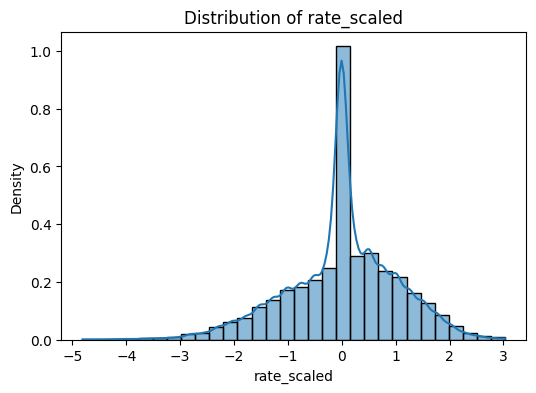

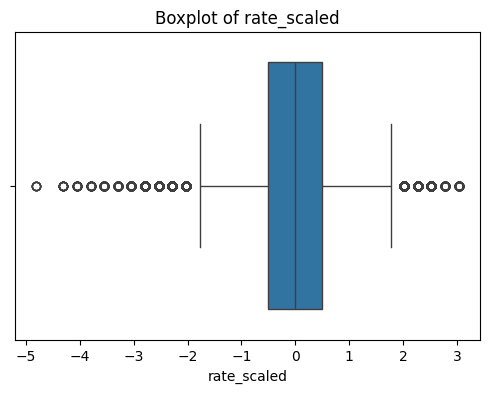

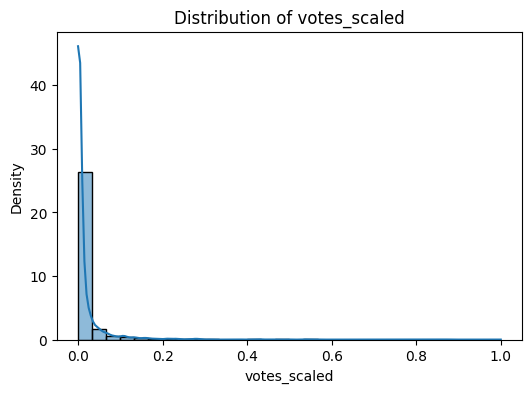

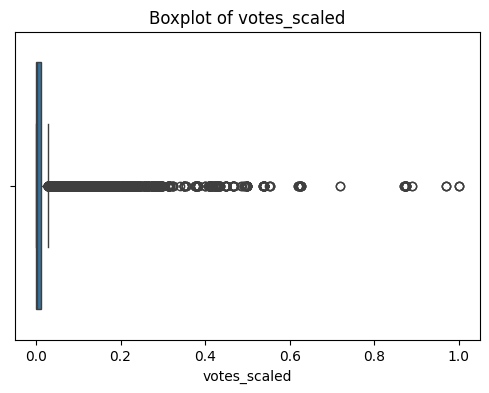

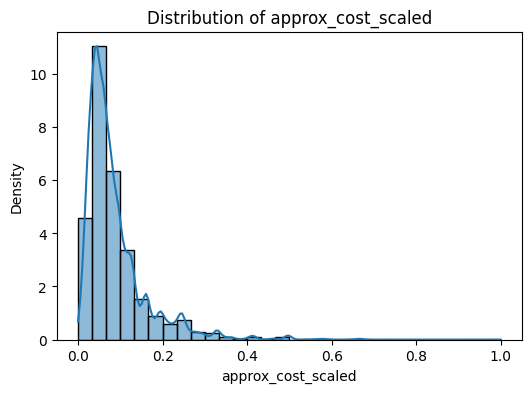

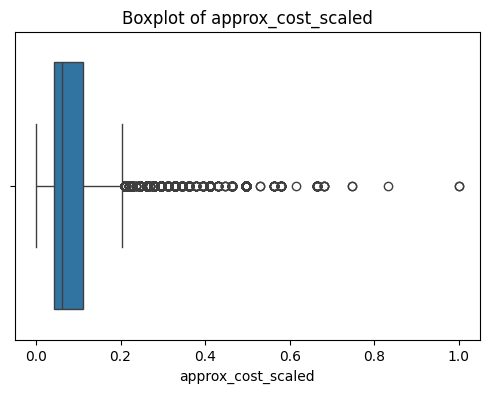

In [ ]:
# Univariate Analysis for numerical columns

# Here we plot histogram and boxplot for all the numeric columns

# Histogram has a smooth curve showing probability density
# We can see how the values are distributed for each numeric column
# We can see if our scaling worked correctly and check for skewness or unusal patterns

# Boxplot shows median, 25th and 75th percentile, whiskers, and outliers
# This can detect outliers which are points outside whiskers of the boxplot of the numeric columns
# We can check spread of values and verify our scaling of values of the numeric columns

num_cols = ["rate_scaled", "votes_scaled", "approx_cost_scaled"]
for col in num_cols:
    plt.figure(figsize = (6,4))
    sns.histplot(df[col].dropna(), kde = True, bins = 30, stat = "density")
    plt.title(f"Distribution of {col}")
    plt.show()
    plt.figure(figsize = (6,4))
    sns.boxplot(x = df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

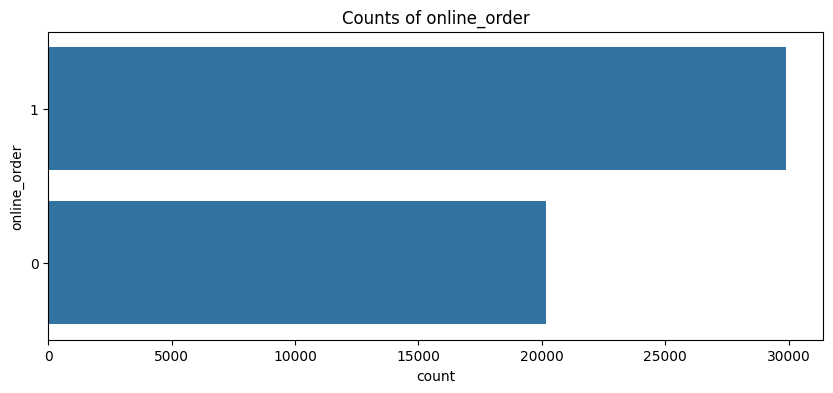

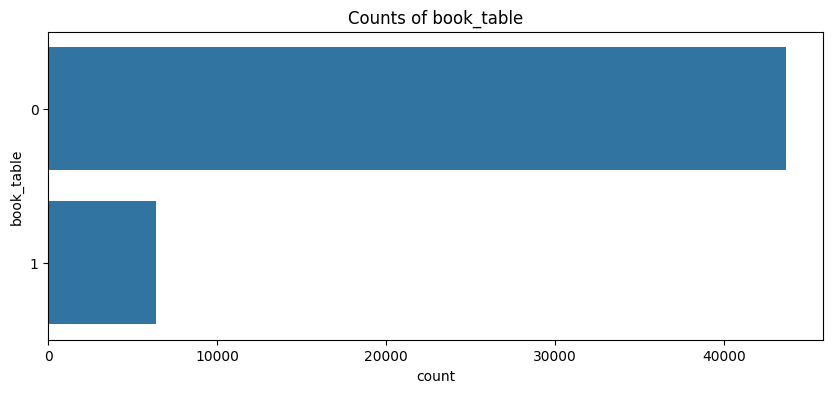

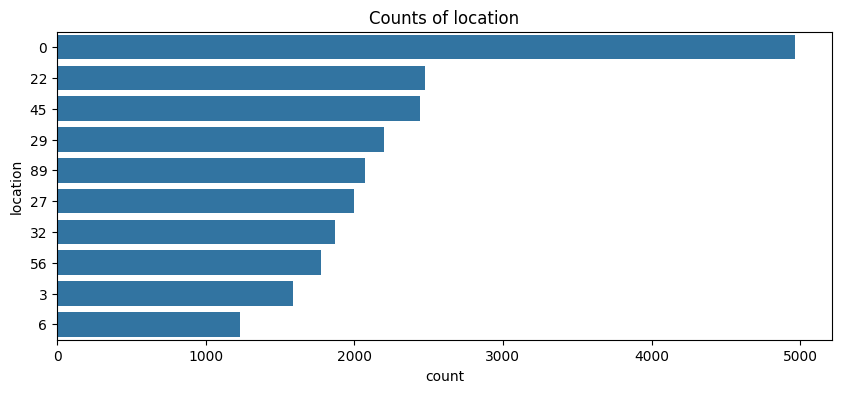

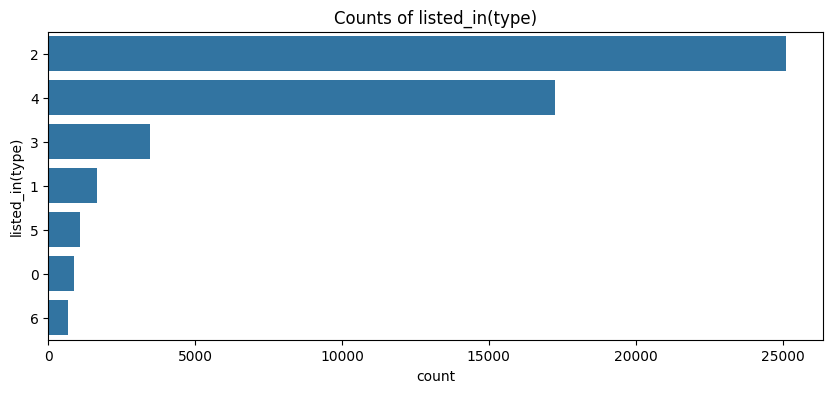

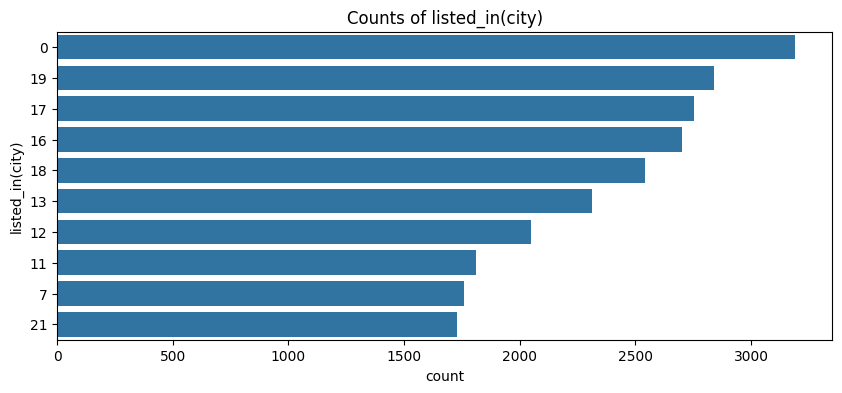

In [ ]:
# Univariate analysis for categorical columns

# Here we create a bar plot of counts for each category in all the categorical columns
# We count how many times each category occurs and keep top 10 most frequent categories

# This plot will help us check which category distribution, detect imbalance, and give a good data cleaning insight for the categorical columns

for col in cat_cols:
    plt.figure(figsize = (10,4))
    top_values = df[col].value_counts().nlargest(10).index
    sns.countplot(y = df[col], order = top_values)
    plt.title(f"Counts of {col}")
    plt.show()

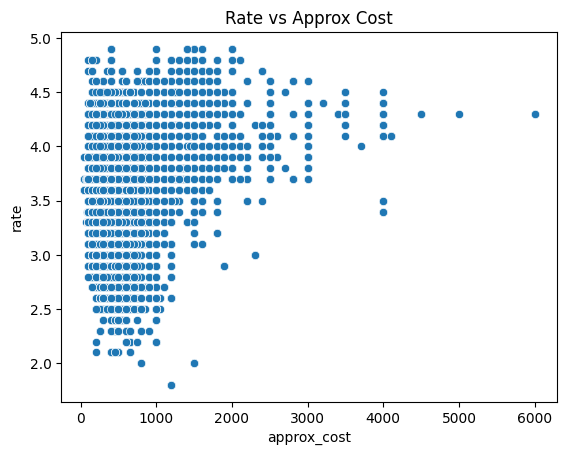

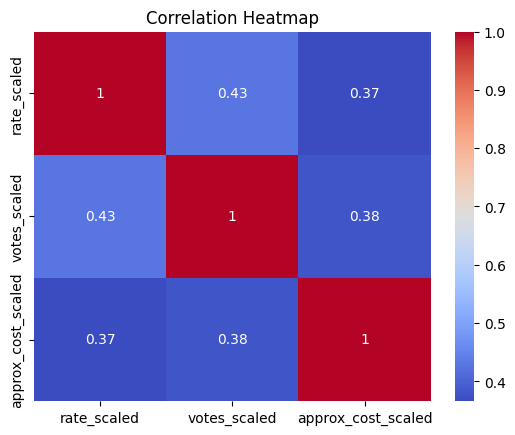

In [ ]:
# Bivariate analysis for numerical columns

# Here we create a scatterplot for rate vs approx_cost and create a heatmap for all the numeric columns

# We create a scatterplot to show the relationship between rate and approx_cost
# This can give useful insights such as are expensive restaurants rated higher and are there any outliers in the dataset

# We compute a correlation matrix for the numeric columns
# Correlation shows how strongly variables move together
# This helps us decide which features are related which can impact feature selection for any machine learning models

sns.scatterplot(x = "approx_cost", y = "rate", data = df)
plt.title("Rate vs Approx Cost")
plt.show()
sns.heatmap(df[num_cols].corr(), annot = True, cmap = "coolwarm")
plt.title("Correlation Heatmap")
plt.show()

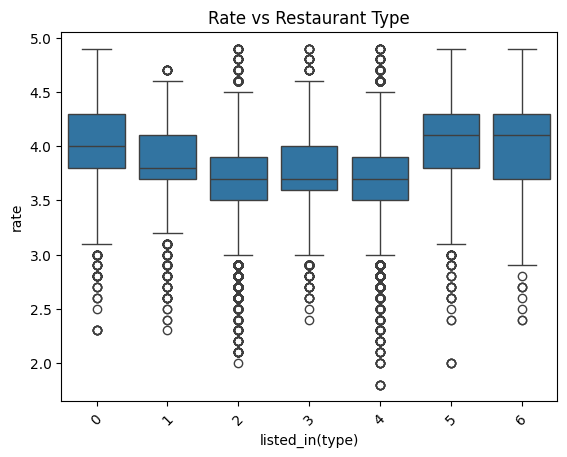

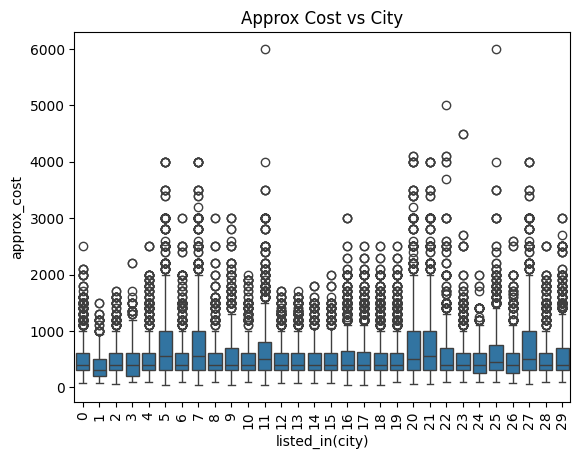

In [ ]:
# Bivariate analysis between numerical and categorical columns

# Here we plot boxplots to show the relationship between these columns

# This boxplot compares ratings across various restaurant types
# It shows types which have higher or lower median ratings
# Helps in identification of outliers in each category

sns.boxplot(x = "listed_in(type)", y = "rate", data = df)
plt.xticks(rotation = 45)
plt.title("Rate vs Restaurant Type")
plt.show()

# This boxplot compares approx_cost across different cities
# It can help to identify cities with cheap or expensive restaurants
# Helps in finding outliers for the dataset

sns.boxplot(x = "listed_in(city)", y = "approx_cost", data = df)
plt.xticks(rotation = 90)
plt.title("Approx Cost vs City")
plt.show()

# Machine Learning

Three features built on top of the preprocessed Zomato dataset:

1. **Restaurant Recommender System** – takes user inputs and suggests restaurants using TF-IDF + cosine similarity.
2. **Customer Sentiment Analysis** – uses VADER to label reviews of recommended restaurants as Positive / Neutral / Negative.
3. **Mini Q&A Chatbot** – retrieves the most relevant review snippets to answer a user's question about a restaurant.



In [ ]:
# Pull location and online_order from original_df as clean strings,
# then merge onto df so we have everything in one place.

import re
import numpy as np
import pandas as pd

# Step 1 – Extract only the two columns that were encoded, keep as strings
# This mirrors the same cleaning done during preprocessing (strip, drop nulls)
# but we stop before LabelEncoder so the values stay human-readable.
orig_str = original_df[['name', 'address', 'location', 'online_order']].copy()
orig_str['location_str']     = orig_str['location'].astype(str).str.strip()
orig_str['online_order_str'] = orig_str['online_order'].astype(str).str.strip()
orig_str = orig_str[['name', 'address', 'location_str', 'online_order_str']]
orig_str = orig_str.drop_duplicates(subset=['name', 'address'])  # avoid one-to-many join

# Step 2 – Merge string columns back onto df using name + address as the key
# All other columns (cuisines, reviews_list, rate_scaled etc.) come directly from df
rec_df = df.merge(orig_str, on=['name', 'address'], how='left')

print(f"rec_df shape: {rec_df.shape}")
print(f"Null location_str: {rec_df['location_str'].isnull().sum()}")
print(f"Unique locations : {rec_df['location_str'].nunique()}")
rec_df[['name', 'location_str', 'cuisines', 'rate', 'approx_cost',
        'online_order_str']].head()

In [ ]:
# MOJIBAKE FIX (updated)
# Two types of garbage exist in the reviews:
#
# Type 1 - actual non-ASCII bytes (garbled sequences like a~x83x82)
#   These are UTF-8 multi-byte sequences misread as Latin-1.
#   Fix: encode to ASCII and drop anything outside the 128-char range.
#
# Type 2 - literal hex strings embedded inside words (youx83x82re)
#   These are escape sequences that got serialised as plain text
#   characters ('x','8','3') somewhere in the scraping pipeline.
#   ASCII encoding won't catch them because x/8/3 are valid ASCII.
#   Fix: regex to remove any 'x' followed by exactly 2 hex digits.

import re

def strip_mojibake(text):
    if pd.isnull(text) or not str(text).strip():
        return ''
    text = str(text)

    # Fix Type 1 - drop actual non-ASCII bytes (emojis, foreign scripts)
    text = text.encode('ascii', errors='ignore').decode('ascii')

    # Fix Type 2 - remove literal hex remnants like x83, x82, x99 inside words
    # Pattern: letter x followed by exactly two hexadecimal digits
    text = re.sub(r'x[0-9a-fA-F]{2}', '', text)

    # Collapse leftover multiple spaces caused by the removals
    text = re.sub(r'\s+', ' ', text).strip()
    return text

rec_df['reviews_list'] = rec_df['reviews_list'].apply(strip_mojibake)

# Sanity check
print('Sample reviews after full mojibake fix:\n')
for review in rec_df['reviews_list'].dropna().head(3):
    print(' *', review[:200])
    print()


In [ ]:
# FEATURE MATRIX
# cuisines → TF-IDF (text similarity)
# rate_scaled, votes_scaled, approx_cost_scaled → already preprocessed, use as-is

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from scipy.sparse import hstack, csr_matrix

# TF-IDF on cuisines column (top 150 terms)
# Each dimension = a cuisine term, value = how important that term is for the restaurant
tfidf_cuisine = TfidfVectorizer(max_features=150)
cuisine_matrix = tfidf_cuisine.fit_transform(rec_df['cuisines'].fillna(''))

# Scaled numeric features are already in df from preprocessing — use directly
num_sparse = csr_matrix(
    rec_df[['rate_scaled', 'votes_scaled', 'approx_cost_scaled']].values
)

# Stack both into one feature matrix: rows = restaurants, cols = features
feature_matrix = hstack([cuisine_matrix, num_sparse])

print("Feature matrix shape:", feature_matrix.shape)
print(f"  {rec_df.shape[0]} restaurants  ×  {feature_matrix.shape[1]} features")

## Step 3 – Restaurant Recommender System

Two-stage ranking:
1. **Hard filter** – drops restaurants that don't match location, budget, or online-order preference.
2. **Soft score** – vectorises the user's cuisine input in the same TF-IDF space, computes cosine similarity, and combines it with the rating:  
   `score = 0.6 × cuisine_similarity + 0.4 × (rate / 5)`

In [ ]:
# RECOMMENDER FUNCTION

def recommend_restaurants(cuisine_pref, location_pref=None, budget=None,
                           online_order_pref=None, top_n=5):
    """
    cuisine_pref      : str  - e.g. 'North Indian', 'Chinese, Biryani'
    location_pref     : str  - partial area name, e.g. 'Koramangala'
    budget            : int  - max approx cost for two people in Rs
    online_order_pref : str  - 'Yes' or 'No'; None = no preference
    top_n             : int  - number of restaurants to return
    """

    # Stage 1: Hard filter using the string columns we merged back
    filtered = rec_df.copy()

    if location_pref:
        filtered = filtered[
            filtered['location_str'].str.contains(location_pref, case=False, na=False)
        ]

    if budget:
        filtered = filtered[filtered['approx_cost'] <= budget]

    if online_order_pref:
        filtered = filtered[
            filtered['online_order_str'].str.strip().str.lower() == online_order_pref.strip().lower()
        ]

    if filtered.empty:
        print('No restaurants match your filters. Try relaxing some constraints.')
        return None

    # Stage 2: Cosine similarity on cuisine
    query_vec   = tfidf_cuisine.transform([cuisine_pref])
    filt_idx    = filtered.index.tolist()
    cuisine_sub = cuisine_matrix[filt_idx]
    sims        = cosine_similarity(query_vec, cuisine_sub).flatten()

    # Stage 3: Combined score
    filtered        = filtered.copy()
    filtered['sim'] = sims
    filtered['score'] = 0.6 * filtered['sim'] + 0.4 * (filtered['rate'] / 5.0)

    # Stage 4: Deduplicate by restaurant name - keep the row with highest score
    # Same restaurant can appear multiple times in the dataset (different branches
    # or duplicate entries) - we keep only the best-scoring entry per unique name
    filtered = (
        filtered
        .sort_values('score', ascending=False)
        .drop_duplicates(subset=['name'], keep='first')
    )

    results = (
        filtered
        .head(top_n)
        [['name', 'location_str', 'cuisines', 'rate',
          'approx_cost', 'online_order_str', 'rest_type', 'score']]
        .rename(columns={'location_str': 'location', 'online_order_str': 'online_order'})
        .reset_index(drop=True)
    )
    results.index += 1
    return results


# USER INPUT
cuisine_input      = input("Enter cuisine preference (e.g. 'North Indian', 'Pizza'): ").strip()
location_input     = input('Enter area/location (or press Enter to skip): ').strip() or None
budget_input       = input('Max budget for 2 people in Rs (or press Enter to skip): ').strip()
online_order_input = input('Want online order option? Yes / No (or press Enter to skip): ').strip() or None

recommendations = recommend_restaurants(
    cuisine_pref      = cuisine_input,
    location_pref     = location_input,
    budget            = int(budget_input) if budget_input else None,
    online_order_pref = online_order_input
)

if recommendations is not None:
    print('\n Top Restaurant Recommendations:\n')
    display(recommendations)


## Step 4 – Customer Sentiment Analysis

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) runs directly on the
already-cleaned `reviews_list` column in `df` — no extra cleaning needed.

| Compound score | Label |
|---|---|
| ≥ 0.05 | Positive |
| ≤ −0.05 | Negative |
| in between | Neutral |

In [ ]:
# SENTIMENT ANALYSIS – VADER

import nltk
import matplotlib.pyplot as plt
import seaborn as sns

nltk.download('vader_lexicon', quiet=True)
from nltk.sentiment.vader import SentimentIntensityAnalyzer

sia = SentimentIntensityAnalyzer()

def get_sentiment_label(text):
    if not text or pd.isnull(text):
        return 'No Review'
    score = sia.polarity_scores(str(text))['compound']
    if score >= 0.05:   return 'Positive'
    elif score <= -0.05: return 'Negative'
    else:                return 'Neutral'

def get_sentiment_score(text):
    if not text or pd.isnull(text):
        return 0.0
    return sia.polarity_scores(str(text))['compound']

if recommendations is not None:
    rec_names = recommendations['name'].tolist()

    # Filter rec_df for recommended restaurants and run sentiment on reviews_list
    rec_rows = rec_df[rec_df['name'].isin(rec_names)].copy()
    rec_rows['sentiment']       = rec_rows['reviews_list'].apply(get_sentiment_label)
    rec_rows['sentiment_score'] = rec_rows['reviews_list'].apply(get_sentiment_score)

    # Aggregate: dominant label + average score per restaurant
    sentiment_summary = (
        rec_rows
        .groupby('name', as_index=False)
        .agg(
            overall_sentiment = ('sentiment',       lambda x: x.mode()[0]),
            avg_score         = ('sentiment_score', 'mean')
        )
    )

    print("\n📊 Sentiment Analysis of Recommended Restaurants:\n")
    display(sentiment_summary)

    plt.figure(figsize=(10, 4))
    sns.barplot(
        data    = sentiment_summary.sort_values('avg_score', ascending=False),
        x       = 'name',
        y       = 'avg_score',
        palette = 'RdYlGn'
    )
    plt.axhline(0, color='gray', linestyle='--', linewidth=0.8)
    plt.xticks(rotation=45, ha='right')
    plt.title('Average Sentiment Score for Recommended Restaurants', fontsize=13)
    plt.ylabel('Compound Score  (−1 Very Negative → +1 Very Positive)')
    plt.tight_layout()
    plt.show()
else:
    print("Run the recommender cell first.")

## Step 5 – Mini Review-Based Q&A Chatbot

Retrieval-based approach (no LLM needed):
1. Fetches all reviews for the chosen restaurant from `reviews_list`.
2. Splits them into sentence-level snippets.
3. Vectorises snippets + the user question with TF-IDF.
4. Returns the top snippets with highest cosine similarity to the question.

In [ ]:
# MINI Q&A CHATBOT - RETRIEVAL FROM reviews_list

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

def answer_question(restaurant_name, question, top_k=3):
    """
    restaurant_name : str - must match a name in rec_df (case-insensitive)
    question        : str - any natural language question
    top_k           : int - number of snippets to return
    """

    rows = rec_df[rec_df['name'].str.lower() == restaurant_name.lower()]

    if rows.empty:
        print(f"No restaurant named '{restaurant_name}' found. Check the spelling.")
        return

    # Deduplicate reviews before splitting - same review text appearing in
    # multiple rows (duplicate dataset entries) would inflate certain snippets
    unique_reviews = rows['reviews_list'].dropna().astype(str).unique().tolist()
    all_reviews = ' '.join(unique_reviews)

    # Split into sentence-level snippets
    snippets = re.split(r'[./\n]+', all_reviews)
    snippets = [s.strip() for s in snippets if len(s.strip()) > 20]

    # Deduplicate snippets themselves - remove exact duplicate sentences
    seen_snippets = set()
    unique_snippets = []
    for s in snippets:
        if s.lower() not in seen_snippets:
            seen_snippets.add(s.lower())
            unique_snippets.append(s)
    snippets = unique_snippets

    if not snippets:
        print('Not enough review text to answer this question.')
        return

    # TF-IDF: vectorise snippets + question in the same vocabulary space
    corpus = snippets + [question]
    vectorizer = TfidfVectorizer(stop_words='english')
    try:
        tfidf_mat = vectorizer.fit_transform(corpus)
        query_vec = tfidf_mat[-1]
        snip_vecs = tfidf_mat[:-1]
        sims      = cosine_similarity(query_vec, snip_vecs).flatten()
    except Exception as e:
        print(f'Could not process reviews: {e}')
        return

    top_indices = sims.argsort()[::-1][:top_k * 2]

    print(f"\n Chatbot Answer for '{restaurant_name}'")
    print(f'    Question: {question}\n')

    shown, seen = 0, set()
    for idx in top_indices:
        snippet = snippets[idx].strip().capitalize()
        if snippet in seen or len(snippet) < 20 or sims[idx] < 0.01:
            continue
        print(f'  {snippet}')
        seen.add(snippet)
        shown += 1
        if shown >= top_k:
            break

    if shown == 0:
        print("  Couldn't find relevant info - try asking about food, service, or ambience.")


# USER INPUT - Q&A LOOP
# Type your question and press Enter. Type 'exit' or 'quit' to stop.

if recommendations is not None:
    print('Restaurants you can ask about:')
    for name in recommendations['name'].tolist():
        print(f'  * {name}')

restaurant_choice = input('\nEnter restaurant name to ask about: ').strip()
print("\nAsk anything about this restaurant. Type 'exit' or 'quit' to stop.\n")

while True:
    user_question = input('Your question: ').strip()
    if user_question.lower() in ['exit', 'quit', 'no', 'stop']:
        break
    if not user_question:
        print('Please enter a question.')
        continue
    answer_question(restaurant_choice, user_question)
    print()

print('\nThanks for using the Restaurant Assistant!')
